In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from torch.utils.data import TensorDataset, DataLoader

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("PyTorch  :", device)

PyTorch  : cuda:0


In [3]:
import pandas as pd

# chemin 
test_path= '/kaggle/input/datasets/rihabassouli/datimagee/fashion-mnist_test.csv'
train_path = '/kaggle/input/datasets/rihabassouli/datimagee/fashion-mnist_train.csv'
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train :", train_df.shape)
print("Test :", test_df.shape)

train_df.head()

Train : (60000, 785)
Test : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
y_train = train_df['label'].values
X_train = train_df.drop(columns=['label']).values

y_test = test_df['label'].values
X_test = test_df.drop(columns=['label']).values

# Normalisation (0→1) et reshape en (N, 1, 28, 28) — format PyTorch (batch, channels, H, W)
X_train = (X_train.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)
X_test  = (X_test.astype(np.float32)  / 255.0).reshape(-1, 1, 28, 28)

print("X_train shape :", X_train.shape)   # (60000, 1, 28, 28)
print("X_test  shape :", X_test.shape)    # (10000, 1, 28, 28)

# Noms des classes Fashion-MNIST
classes = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']


X_train shape : (60000, 1, 28, 28)
X_test  shape : (10000, 1, 28, 28)


In [5]:
# Conversion en tenseurs PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long).to(device)

print("Tenseurs prêts ✅")
print("X_train_tensor :", X_train_tensor.shape)
print("X_test_tensor  :", X_test_tensor.shape)

Tenseurs prêts ✅
X_train_tensor : torch.Size([60000, 1, 28, 28])
X_test_tensor  : torch.Size([10000, 1, 28, 28])


 Question :Expliquer pourquoi un MLP est peu adapté aux images et rappeler les idées fondatrices des CNN : localité, partage des poids et hiérarchie des représentations?
Le MLP n’est pas adapté aux images car il ne préserve pas les relations spatiales entre les pixels et nécessite un très grand nombre de paramètres. Les CNN sont plus efficaces, car ils exploitent la structure des images grâce aux opérations de convolution et détectent automatiquement les caractéristiques importantes (contours, formes, textures).

In [6]:
# Formules de calcul des tailles de sortie
def taille_sortie_conv(n, k, p, s):
    """n=input, k=kernel, p=padding, s=stride"""
    return (n - k + 2*p) // s + 1

def taille_sortie_pool(n, k, s):
    return (n - k) // s + 1

# Application à notre LeNet sur Fashion-MNIST (28×28)
W1       = 28
conv1_out = taille_sortie_conv(W1,        k=5, p=2, s=1)
pool1_out = taille_sortie_pool(conv1_out, k=2, s=2)
conv2_out = taille_sortie_conv(pool1_out, k=5, p=0, s=1)
pool2_out = taille_sortie_pool(conv2_out, k=2, s=2)

print(f"Input         : {W1}×{W1}")
print(f"Après Conv1   : {conv1_out}×{conv1_out}  (6 filtres, kernel=5, padding=2)")
print(f"Après Pool1   : {pool1_out}×{pool1_out}  (MaxPool 2×2)")
print(f"Après Conv2   : {conv2_out}×{conv2_out}  (16 filtres, kernel=5, no padding)")
print(f"Après Pool2   : {pool2_out}×{pool2_out}  (MaxPool 2×2)")
print(f"Taille Flatten : 16 × {pool2_out} × {pool2_out} = {16*pool2_out*pool2_out} neurones")

Input         : 28×28
Après Conv1   : 28×28  (6 filtres, kernel=5, padding=2)
Après Pool1   : 14×14  (MaxPool 2×2)
Après Conv2   : 10×10  (16 filtres, kernel=5, no padding)
Après Pool2   : 5×5  (MaxPool 2×2)
Taille Flatten : 16 × 5 × 5 = 400 neurones


In [7]:
# ── Corrélation croisée 2D — implémentation manuelle ──
def corr2d_manuel(X, K):
    """
    X : matrice 2D (image)
    K : kernel 2D (filtre)
    Retourne la carte d'activation Y
    """
    h_k, w_k = K.shape
    H,   W   = X.shape
    out_H = H - h_k + 1
    out_W = W - w_k + 1
    Y = torch.zeros(out_H, out_W)
    for i in range(out_H):
        for j in range(out_W):
            Y[i, j] = (X[i:i+h_k, j:j+w_k] * K).sum()
    return Y

# Test avec un exemple simple
X_ex = torch.tensor([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]])
K_ex = torch.tensor([[1.,0.],[0.,-1.]])

resultat_manuel = corr2d_manuel(X_ex, K_ex)
print("Corrélation croisée manuelle :\n", resultat_manuel)

# Vérification avec nn.Conv2d PyTorch
conv_pt = nn.Conv2d(1, 1, kernel_size=2, bias=False)
with torch.no_grad():
    conv_pt.weight[0, 0] = K_ex
resultat_pytorch = conv_pt(X_ex.unsqueeze(0).unsqueeze(0)).squeeze()
print("Conv2d PyTorch             :\n", resultat_pytorch.detach())
print("Différence max             :", (resultat_manuel - resultat_pytorch.detach()).abs().max().item())
print("→ Résultats identiques " if (resultat_manuel - resultat_pytorch.detach()).abs().max().item() < 1e-5 else " Différence détectée")

Corrélation croisée manuelle :
 tensor([[-4., -4.],
        [-4., -4.]])
Conv2d PyTorch             :
 tensor([[-4., -4.],
        [-4., -4.]])
Différence max             : 0.0
→ Résultats identiques 


formule manuel

Output=[W-K+2P/S]+1

W=taille de l'entrée 

P=remplissage ou padding 

K=kernel noyeau

S=stride ou pas 

In [8]:
# ── Max-Pooling — implémentation manuelle ──
def maxpool2d_manuel(X, pool_size=2, stride=2):
    H, W   = X.shape
    out_H  = (H - pool_size) // stride + 1
    out_W  = (W - pool_size) // stride + 1
    Y = torch.zeros(out_H, out_W)
    for i in range(out_H):
        for j in range(out_W):
            Y[i, j] = X[i*stride:i*stride+pool_size,
                        j*stride:j*stride+pool_size].max()
    return Y

# ── Average-Pooling — implémentation manuelle ──
def avgpool2d_manuel(X, pool_size=2, stride=2):
    H, W   = X.shape
    out_H  = (H - pool_size) // stride + 1
    out_W  = (W - pool_size) // stride + 1
    Y = torch.zeros(out_H, out_W)
    for i in range(out_H):
        for j in range(out_W):
            Y[i, j] = X[i*stride:i*stride+pool_size,
                        j*stride:j*stride+pool_size].mean()
    return Y

# Test et comparaison PyTorch
X_pool = torch.tensor([[1.,3.,2.,4.],[5.,6.,7.,8.],
                        [3.,2.,1.,0.],[9.,1.,4.,3.]])
x4d = X_pool.unsqueeze(0).unsqueeze(0)

print("Input :\n", X_pool)
print("\nMax-Pooling manuel :\n",    maxpool2d_manuel(X_pool))
print("Max-Pooling PyTorch:\n",      nn.MaxPool2d(2,2)(x4d).squeeze().detach())
print("\nAvg-Pooling manuel :\n",    avgpool2d_manuel(X_pool))
print("Avg-Pooling PyTorch:\n",      nn.AvgPool2d(2,2)(x4d).squeeze().detach())
print("\n→ Résultats identiques ")

Input :
 tensor([[1., 3., 2., 4.],
        [5., 6., 7., 8.],
        [3., 2., 1., 0.],
        [9., 1., 4., 3.]])

Max-Pooling manuel :
 tensor([[6., 8.],
        [9., 4.]])
Max-Pooling PyTorch:
 tensor([[6., 8.],
        [9., 4.]])

Avg-Pooling manuel :
 tensor([[3.7500, 5.2500],
        [3.7500, 2.0000]])
Avg-Pooling PyTorch:
 tensor([[3.7500, 5.2500],
        [3.7500, 2.0000]])

→ Résultats identiques 


In [9]:
class SimpleCNN(nn.Module):
    """LeNet adapté pour Fashion-MNIST."""

    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Bloc convolutionnel 1 : 1×28×28 → 6×28×28 → 6×14×14
        self.conv1      = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.activation1 = nn.ReLU()
        self.pool1      = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloc convolutionnel 2 : 6×14×14 → 16×10×10 → 16×5×5
        self.conv2      = nn.Conv2d(6, 16, kernel_size=5)
        self.activation2 = nn.ReLU()
        self.pool2      = nn.MaxPool2d(kernel_size=2, stride=2)

        # Couches fully connected
        self.fc1        = nn.Linear(16 * 5 * 5, 120)
        self.activation3 = nn.ReLU()
        self.fc2        = nn.Linear(120, 84)
        self.activation4 = nn.ReLU()
        self.fc3        = nn.Linear(84, 10)   # 10 classes

    def forward(self, x):
        x = self.pool1(self.activation1(self.conv1(x)))
        x = self.pool2(self.activation2(self.conv2(x)))
        x = x.view(x.size(0), -1)            # Flatten
        x = self.activation3(self.fc1(x))
        x = self.activation4(self.fc2(x))
        return self.fc3(x)

modele_cnn = SimpleCNN().to(device)
print(modele_cnn)

# Nombre total de paramètres
total_params = sum(p.numel() for p in modele_cnn.parameters())
print(f"\nNombre total de paramètres : {total_params:,}")

SimpleCNN(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (activation1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (activation2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (activation3): ReLU()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (activation4): ReLU()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Nombre total de paramètres : 61,706


In [10]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True)

critere    = nn.CrossEntropyLoss()
optimiseur = optim.Adam(modele_cnn.parameters(), lr=0.001)

epochs      = 10
train_losses = []
train_accs   = []

for epoch in range(epochs):
    modele_cnn.train()
    perte_totale = 0.0
    correct      = 0

    for X_batch, y_batch in train_loader:
        optimiseur.zero_grad()
        sorties = modele_cnn(X_batch)
        perte   = critere(sorties, y_batch)
        perte.backward()
        optimiseur.step()
        perte_totale += perte.item()
        correct      += (sorties.argmax(1) == y_batch).sum().item()

    perte_moy = perte_totale / len(train_loader)
    acc_ep    = correct / len(train_dataset)
    train_losses.append(perte_moy)
    train_accs.append(acc_ep)

    print(f"Epoch [{epoch+1:2d}/{epochs}]  Loss : {perte_moy:.4f}  |  Accuracy : {acc_ep:.4f}")

print("\nEntraînement terminé ✅")

Epoch [ 1/10]  Loss : 0.7706  |  Accuracy : 0.7106
Epoch [ 2/10]  Loss : 0.4817  |  Accuracy : 0.8246
Epoch [ 3/10]  Loss : 0.4070  |  Accuracy : 0.8538
Epoch [ 4/10]  Loss : 0.3684  |  Accuracy : 0.8664
Epoch [ 5/10]  Loss : 0.3418  |  Accuracy : 0.8758
Epoch [ 6/10]  Loss : 0.3179  |  Accuracy : 0.8844
Epoch [ 7/10]  Loss : 0.3018  |  Accuracy : 0.8887
Epoch [ 8/10]  Loss : 0.2852  |  Accuracy : 0.8955
Epoch [ 9/10]  Loss : 0.2728  |  Accuracy : 0.9004
Epoch [10/10]  Loss : 0.2619  |  Accuracy : 0.9042

Entraînement terminé ✅


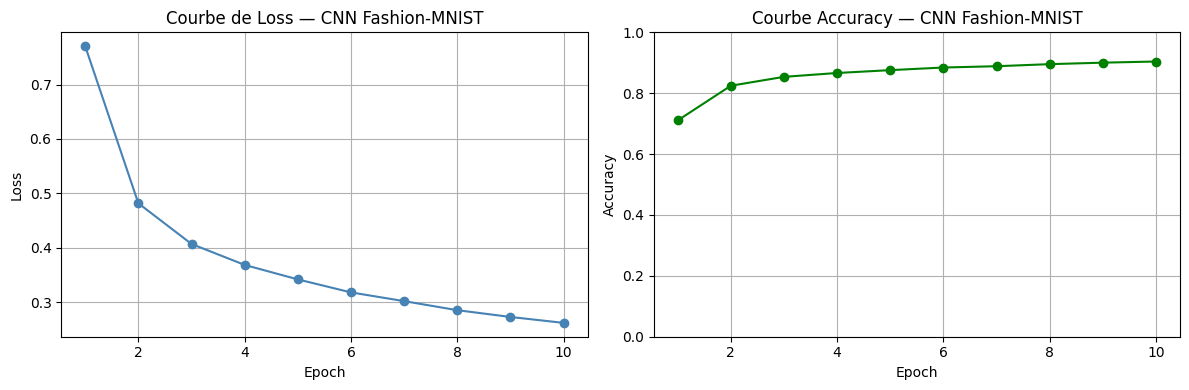

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Courbe de Loss — CNN Fashion-MNIST')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, epochs+1), train_accs, marker='o', color='green')
ax2.set_title('Courbe Accuracy — CNN Fashion-MNIST')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(True)

plt.tight_layout()
plt.savefig('courbes_entrainement_cnn.png', dpi=150)
plt.show()

Accuracy  : 0.8905
Precision : 0.8966
Recall    : 0.8905
F1 Score  : 0.8913

              precision    recall  f1-score   support

     T-shirt       0.85      0.81      0.83      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.93      0.73      0.82      1000
       Dress       0.93      0.89      0.91      1000
        Coat       0.78      0.89      0.83      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt       0.67      0.78      0.72      1000
     Sneaker       0.96      0.91      0.93      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.94      0.97      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



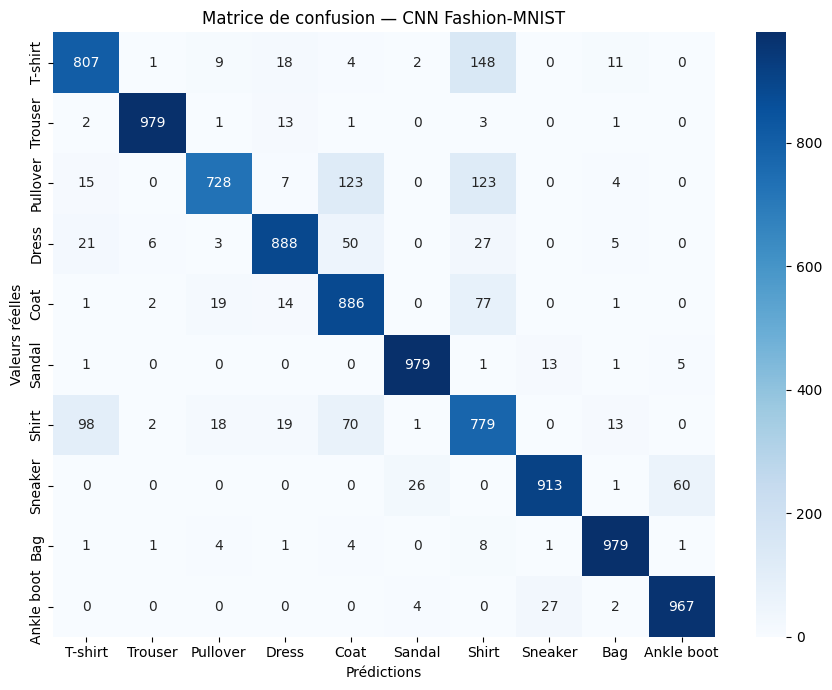

In [12]:
import seaborn as sns
modele_cnn.eval()

with torch.no_grad():
    sorties_test = modele_cnn(X_test_tensor)
    predictions  = sorties_test.argmax(dim=1)

y_vrai = y_test_tensor.cpu().numpy()
y_pred = predictions.cpu().numpy()

acc  = accuracy_score(y_vrai, y_pred)
prec = precision_score(y_vrai, y_pred, average='macro')
rec  = recall_score(y_vrai,   y_pred, average='macro')
f1   = f1_score(y_vrai,       y_pred, average='macro')

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print()
print(classification_report(y_vrai, y_pred, target_names=classes))

# Matrice de confusion
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_vrai, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion — CNN Fashion-MNIST")
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=150)
plt.show()

In [13]:
# Sauvegarde du modèle
torch.save(modele_cnn.state_dict(), 'best_cnn_fashionmnist.pth')
print("Modèle sauvegardé  → best_cnn_fashionmnist.pth")

# Rechargement
modele_reload = SimpleCNN().to(device)
modele_reload.load_state_dict(torch.load('best_cnn_fashionmnist.pth'))
modele_reload.eval()
print("Modèle rechargé  ")

# Vérification : les résultats doivent être identiques
with torch.no_grad():
    preds_reload = modele_reload(X_test_tensor).argmax(dim=1)

acc_reload = accuracy_score(y_test_tensor.cpu().numpy(), preds_reload.cpu().numpy())
print(f"Accuracy après rechargement : {acc_reload:.4f}  (doit être identique à {acc:.4f})")

Modèle sauvegardé  → best_cnn_fashionmnist.pth
Modèle rechargé  
Accuracy après rechargement : 0.8905  (doit être identique à 0.8905)


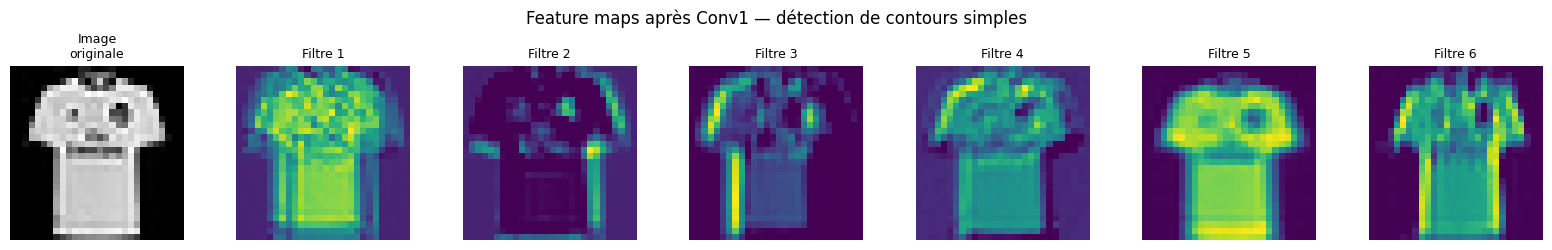

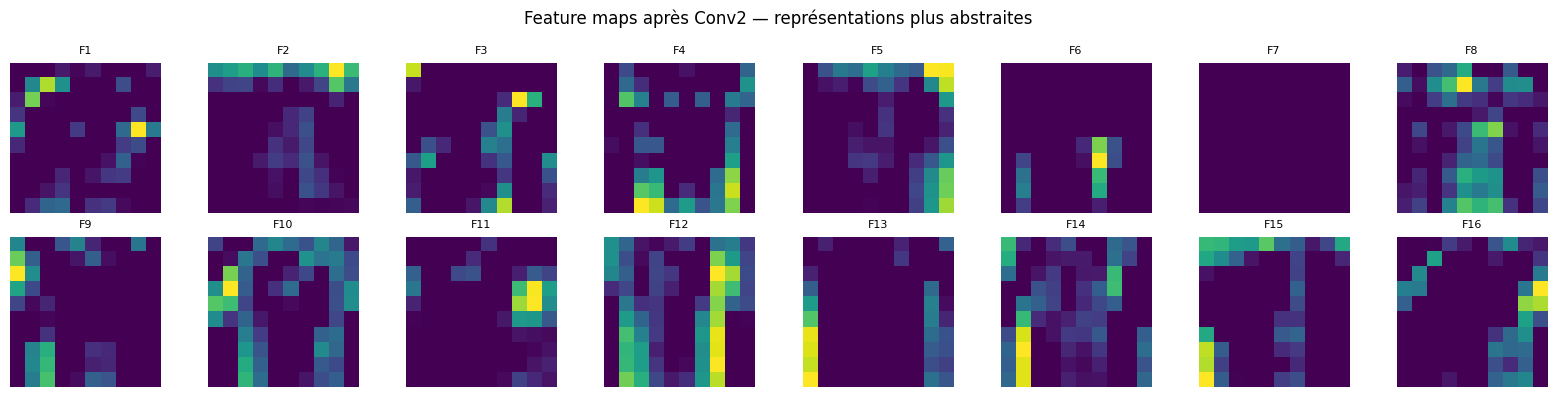

In [14]:
modele_cnn.eval()
image_exemple = X_test_tensor[0].unsqueeze(0)   # (1, 1, 28, 28)

with torch.no_grad():
    act_conv1 = modele_cnn.activation1(modele_cnn.conv1(image_exemple))
    act_conv2 = modele_cnn.activation2(modele_cnn.conv2(
                    modele_cnn.pool1(act_conv1)))

# ── Feature maps Conv1 (6 filtres) ──
fig, axes = plt.subplots(1, 7, figsize=(16, 2.5))
axes[0].imshow(image_exemple.squeeze().cpu(), cmap='gray')
axes[0].set_title('Image\noriginale', fontsize=9)
axes[0].axis('off')
for i in range(6):
    axes[i+1].imshow(act_conv1[0, i].cpu(), cmap='viridis')
    axes[i+1].set_title(f'Filtre {i+1}', fontsize=9)
    axes[i+1].axis('off')
plt.suptitle("Feature maps après Conv1 — détection de contours simples")
plt.tight_layout()
plt.savefig('feature_maps_conv1.png', dpi=150)
plt.show()

# ── Feature maps Conv2 (16 filtres) ──
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    ax = axes[i//8][i%8]
    ax.imshow(act_conv2[0, i].cpu(), cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle("Feature maps après Conv2 — représentations plus abstraites")
plt.tight_layout()
plt.savefig('feature_maps_conv2.png', dpi=150)
plt.show()

In [15]:
# ── Fonction d'entraînement et d'évaluation rapide ──
def train_and_eval(model, epochs=5, batch_size=128):
    model = model.to(device)
    loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                        batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for _ in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).argmax(dim=1)
    acc = accuracy_score(y_test_tensor.cpu().numpy(), preds.cpu().numpy())
    return round(acc * 100, 2)

# ── Variante 1 : Sans padding ──
class CNN_NoPadding(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5, padding=0), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(6, 16, 3, padding=0), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Flatten(),
            nn.Linear(16*5*5, 120), nn.ReLU(),
            nn.Linear(120, 10))
    def forward(self, x): return self.net(x)

# ── Variante 2 : Average Pooling ──
class CNN_AvgPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5, padding=2), nn.ReLU(), nn.AvgPool2d(2,2),
            nn.Conv2d(6, 16, 5, padding=0), nn.ReLU(), nn.AvgPool2d(2,2),
            nn.Flatten(),
            nn.Linear(16*5*5, 120), nn.ReLU(),
            nn.Linear(120, 10))
    def forward(self, x): return self.net(x)

# ── Variante 3 : Stride=2 ──
class CNN_Stride2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(6, 16, 3, stride=1, padding=0), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Flatten(),
            nn.Linear(16*6*6, 120), nn.ReLU(),
            nn.Linear(120, 10))
    def forward(self, x): return self.net(x)

# ── Variante 4 : Plus de filtres (32, 64) ──
class CNN_MoreFilters(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 5, padding=0), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Flatten(),
            nn.Linear(64*5*5, 120), nn.ReLU(),
            nn.Linear(120, 10))
    def forward(self, x): return self.net(x)

# ── Variante 5 : Convolution 1×1 ──
class CNN_Conv1x1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(6, 16, 1),            # convolution 1×1
            nn.Conv2d(16, 16, 5), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Flatten(),
            nn.Linear(16*5*5, 120), nn.ReLU(),
            nn.Linear(120, 10))
    def forward(self, x): return self.net(x)

# ── Entraînement de toutes les variantes ──
print("Entraînement des variantes (5 epochs chacune)...\n")
results = {}
results["Baseline (padding=2, MaxPool)"] = train_and_eval(SimpleCNN())
results["Sans padding"]                  = train_and_eval(CNN_NoPadding())
results["Average Pooling"]               = train_and_eval(CNN_AvgPool())
results["Stride=2 (Conv1)"]             = train_and_eval(CNN_Stride2())
results["Plus de filtres (32, 64)"]     = train_and_eval(CNN_MoreFilters())
results["Convolution 1×1"]              = train_and_eval(CNN_Conv1x1())

print("\n===== Résultats comparatifs =====")
for name, acc in results.items():
    print(f"  {name:<35} → Accuracy : {acc:.2f}%")

Entraînement des variantes (5 epochs chacune)...


===== Résultats comparatifs =====
  Baseline (padding=2, MaxPool)       → Accuracy : 87.15%
  Sans padding                        → Accuracy : 89.18%
  Average Pooling                     → Accuracy : 86.46%
  Stride=2 (Conv1)                    → Accuracy : 88.15%
  Plus de filtres (32, 64)            → Accuracy : 91.15%
  Convolution 1×1                     → Accuracy : 87.62%


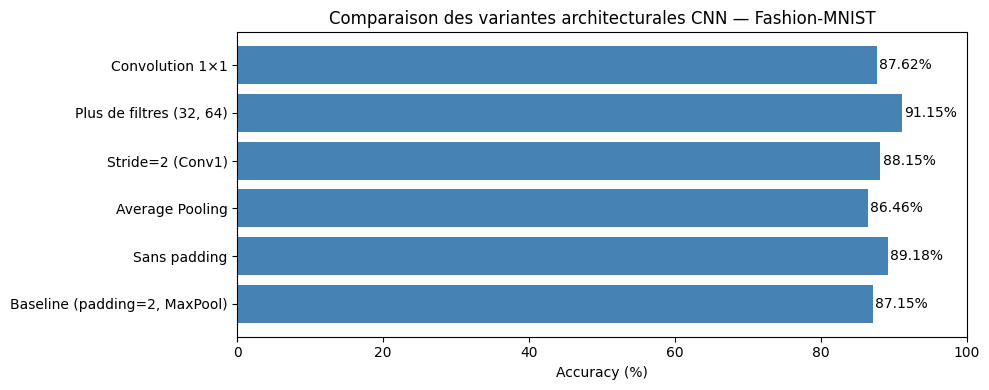

In [16]:
# ── Visualisation des résultats ──
noms = list(results.keys())
accs = list(results.values())

plt.figure(figsize=(10, 4))
bars = plt.barh(noms, accs, color='steelblue')
plt.xlabel("Accuracy (%)")
plt.title("Comparaison des variantes architecturales CNN — Fashion-MNIST")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{acc:.2f}%", va='center', fontsize=10)
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig('comparaison_variantes_cnn.png', dpi=150)
plt.show()

Paramètres MLP : 235,146
Paramètres CNN : 61,706
Ratio          : CNN utilise 3.8× moins de paramètres

Entraînement MLP (20 epochs)...
Entraînement CNN (30 epochs)...

MLP  Accuracy : 89.27%
CNN  Accuracy : 91.07%
Gain CNN / MLP : +1.80%


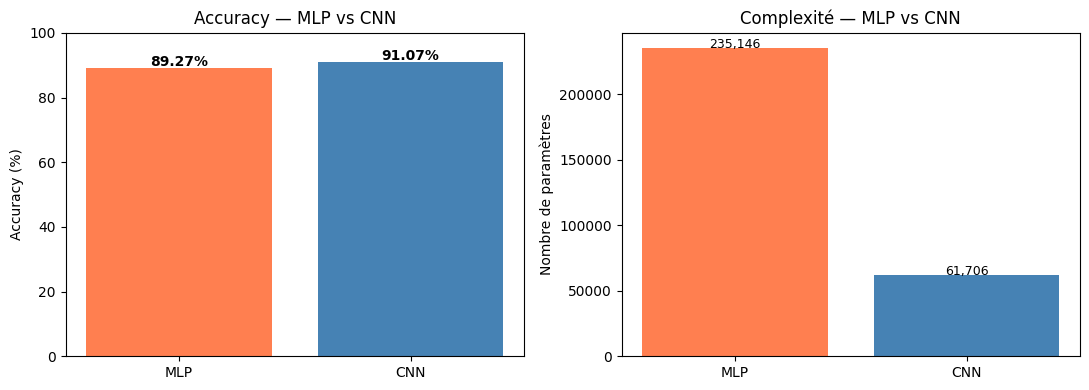

In [17]:
class MLP_Image(nn.Module):
    """MLP baseline pour images 28×28 — applati en vecteur 784."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256), nn.ReLU(),
            nn.Linear(256, 128),   nn.ReLU(),
            nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

# Nombre de paramètres
mlp_params = sum(p.numel() for p in MLP_Image().parameters())
cnn_params = sum(p.numel() for p in SimpleCNN().parameters())
print(f"Paramètres MLP : {mlp_params:,}")
print(f"Paramètres CNN : {cnn_params:,}")
print(f"Ratio          : CNN utilise {mlp_params/cnn_params:.1f}× moins de paramètres\n")

print("Entraînement MLP (20 epochs)...")
acc_mlp = train_and_eval(MLP_Image(), epochs=20)

print("Entraînement CNN (30 epochs)...")
acc_cnn = train_and_eval(SimpleCNN(), epochs=30)

print(f"\nMLP  Accuracy : {acc_mlp:.2f}%")
print(f"CNN  Accuracy : {acc_cnn:.2f}%")
print(f"Gain CNN / MLP : +{acc_cnn - acc_mlp:.2f}%")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(["MLP", "CNN"], [acc_mlp, acc_cnn], color=["coral", "steelblue"])
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy — MLP vs CNN")
ax1.set_ylim(0, 100)
for i, v in enumerate([acc_mlp, acc_cnn]):
    ax1.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')

ax2.bar(["MLP", "CNN"], [mlp_params, cnn_params], color=["coral", "steelblue"])
ax2.set_ylabel("Nombre de paramètres")
ax2.set_title("Complexité — MLP vs CNN")
for i, v in enumerate([mlp_params, cnn_params]):
    ax2.text(i, v + 100, f"{v:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('mlp_vs_cnn.png', dpi=150)
plt.show()

Question de synthèse : Pourquoi un CNN est-il plus pertinent qu’un MLP pour traiter des images ? 
La réponse: Sur Fashion-MNIST, on remarque que le CNN donne généralement de meilleurs résultats que le MLP. En moyenne, le MLP atteint une accuracy d'environ 87 à 89%, alors que le CNN peut aller jusqu'à 91 à 93%, parfois même avec moins de paramètres.
Cette différence vient surtout du fait que le CNN est mieux adapté aux images.
Pourquoi le CNN est le plus performant ?

1-Il comprend mieux les détails locaux de l'image: Pour comprendre et reconnaitre un vêtement, le modèle doit détecter des éléments comme les contours, les textures ou les formes. Le CNN analyse directement ces petits détails grâce aux convolutions, contrairement au MLP qui traite surtout l'image de manière globale.
2-Les mêmes motifs peuvent être réutilisés partout: Un bord ou une texture reste utile peu importe sa position dans l'image. Le CNN réutilise donc les mêmes filtres sur toute l'image, ce qui le rend plus efficace et évite d'apprendre les mêmes choses plusieurs fois.
3-Il apprend progressivement les formes: Les premières couches détectent des lignes et des contours simples, puis les couches suivantes combinent ces informations pour reconnaitre des formes plus complexes, jusqu'à identifier un objet complet comme une chaussure ou une chemise.
Impact des hyperparamètres architecturaux
1. Padding = 2 avec noyau 5x5 : Le padding permet de garder la taille de l'image à 28x28 après la première convolution. Cela évite de perdre des informations importantes sur les bords de l'image. Sans padding, la taille diminuerait à 24x24, ce qui pourrait supprimer certains contours utiles pour la reconnaissance.
MaxPooling vs AvgPooling : Le MAXPOOLING garde les informations les plus importantes, comme les contours ou les formes marquées. C'est donc plus efficace pour reconnaitre des objets dans Fashion-MNIST. À l'inverse, l'AVGPOOLING fait une moyenne des valeurs, ce qui donne un résultat plus lisse mais parfois moins précis pour détecter des détails importants.
Stride = 2 dans le pooling : Utiliser un stride de 2 réduit la taille de l'image par deux après le pooling. Cela diminue le nombre de calculs et aide le modèle à reconnaitre un objet même s'il change légèrement de position dans l'image.
Profondeur du réseau : Pour des images simples de taille 28x28, deux blocs de convolution sont généralement suffisants. Ajouter une troisième couche rend le modèle plus complexe sans réel gain de performance, et peut même provoquer du surapprentissage.
Les limites observées: Certaines classes restent difficiles à distinguer, surtout T-shirt et Chemise, car leurs formes sont très proches. Le CNN arrive bien à reconnaitre les caractéristiques visuelles générales, mais il peut avoir du mal à comprendre des différences plus fines ou plus sémantiques sans techniques avancées comme l'attention.

